In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

In [2]:
df=pd.read_csv('smartcart_data.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [3]:
df.shape

(2240, 22)

In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

# Data Preprocessing & EDA

# 1.Handle Missing Values

In [6]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [7]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# 2.Feature Engineering

In [8]:
# Age
df['Age'] = 2026 - df['Year_Birth']

In [9]:
# Customer Joining Days
df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'],dayfirst=True)
reference_date = df['Dt_Customer'].max()
df['Customer_tenure_days']=(reference_date-df['Dt_Customer']).dt.days

In [10]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_days'],
      dtype='object')

In [11]:
# Total Spending
df['Total_Spending']=df['MntWines']+df['MntFruits']+df['MntMeatProducts']+ df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']

In [12]:
# Total Children 
df['Total_Children'] = df['Kidhome']+df['Teenhome']
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [13]:
# Education
df['Education'] = df['Education'].replace({'Basic':'Undergraduate','2n Cycle':'Undergraduate',
                                          'Graduation':'Graduate','PhD':'Postgraduate',
                                          'Master':'Postgraduate'})

In [14]:
# Marital Status
df['Living_with'] = df['Marital_Status'].replace({'Married':'Partner','Together':'Partner',
                                                 'Single':'Alone','Divorced':'Alone',
                                        'Widow':'Alone','Absurd':'Alone','YOLO':'Alone'})

# 3.Drop Columns

In [15]:
cols =['ID','Year_Birth','Marital_Status','Kidhome',
       'Teenhome','Dt_Customer','MntWines','MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']
df_cleaned = df.drop(columns=cols)

In [16]:
df_cleaned.shape

(2240, 15)

In [17]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# 4.Handle Outliers

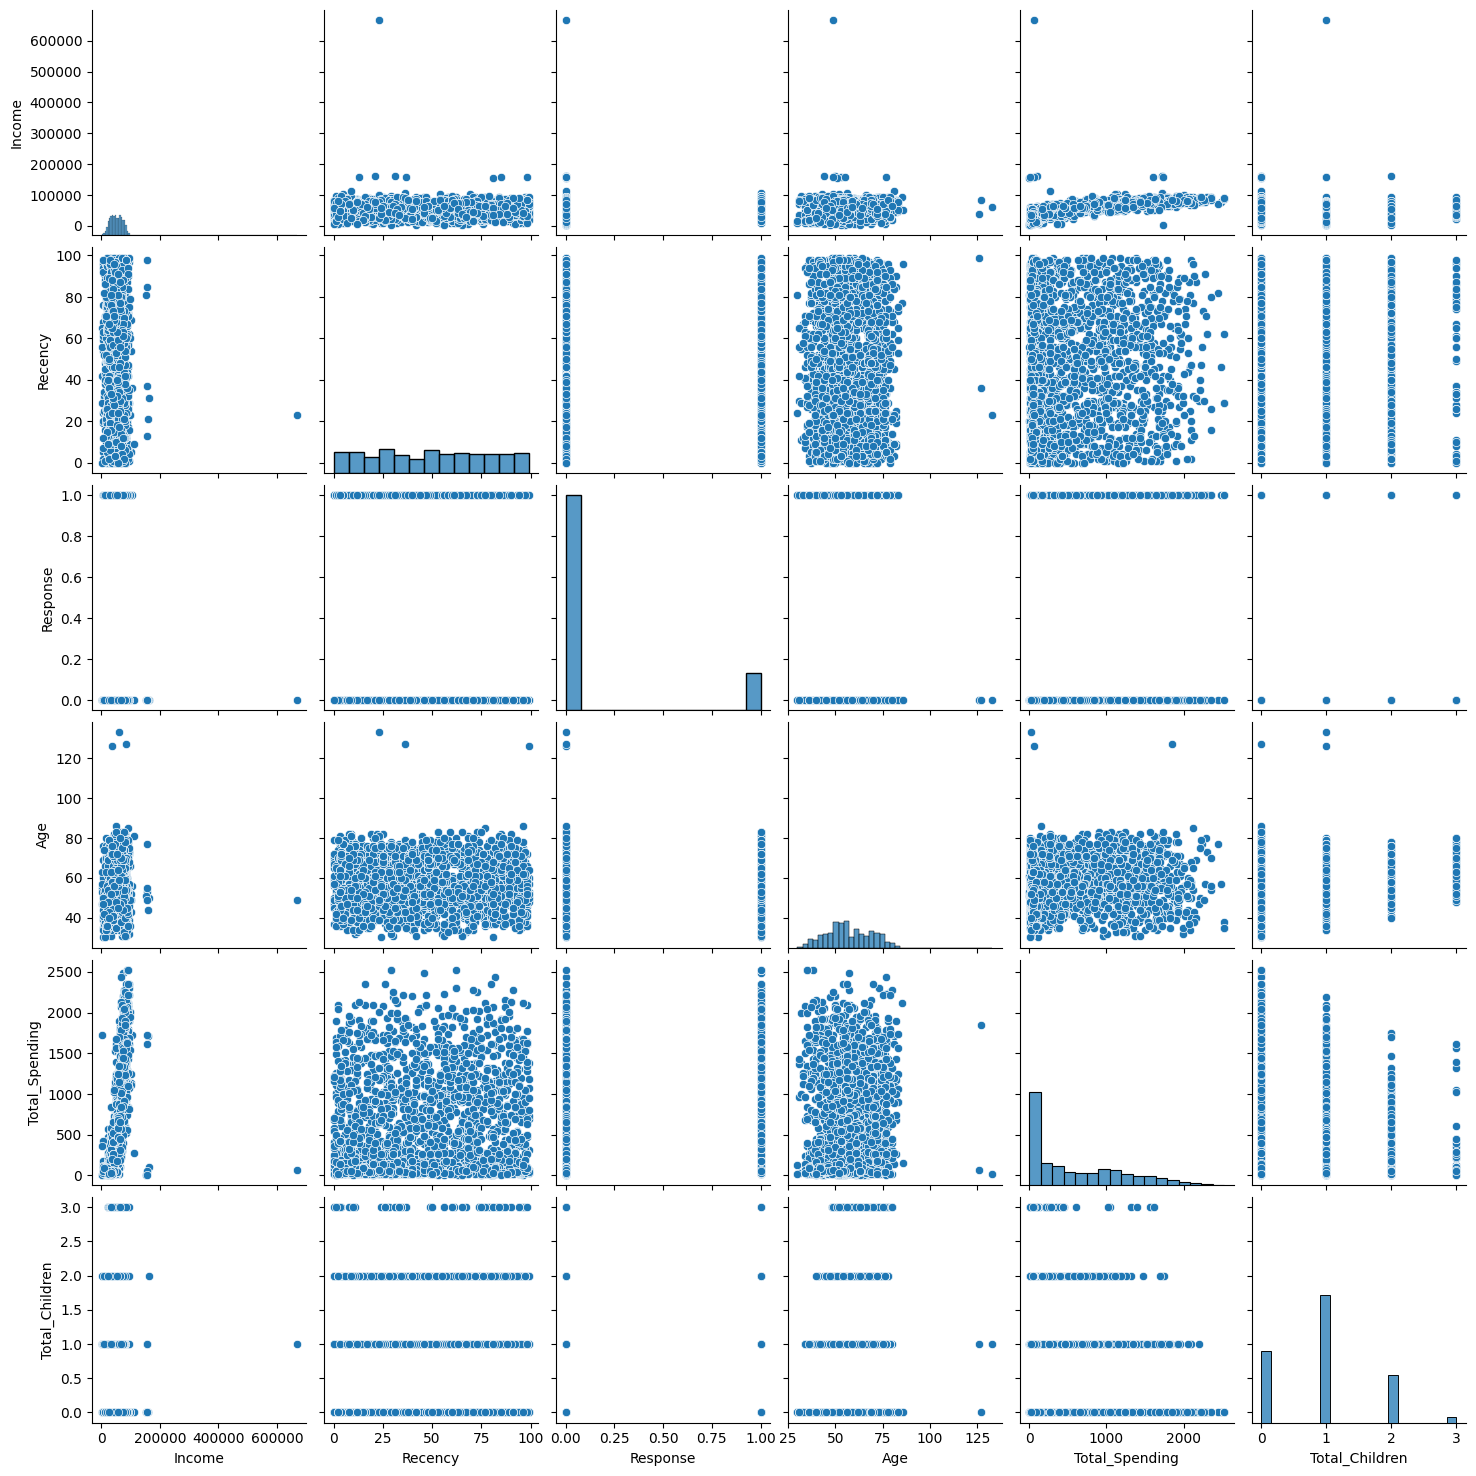

In [18]:
cols = ['Income','Recency','Response','Age','Total_Spending','Total_Children']

sns.pairplot(df_cleaned[cols])

In [19]:
# Remove Outliers
print ('data size with outliers:',len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned['Age']<90) & (df_cleaned['Income']<600_000)]
print ('data size without outliers:',len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


# Heatmap

<Axes: >

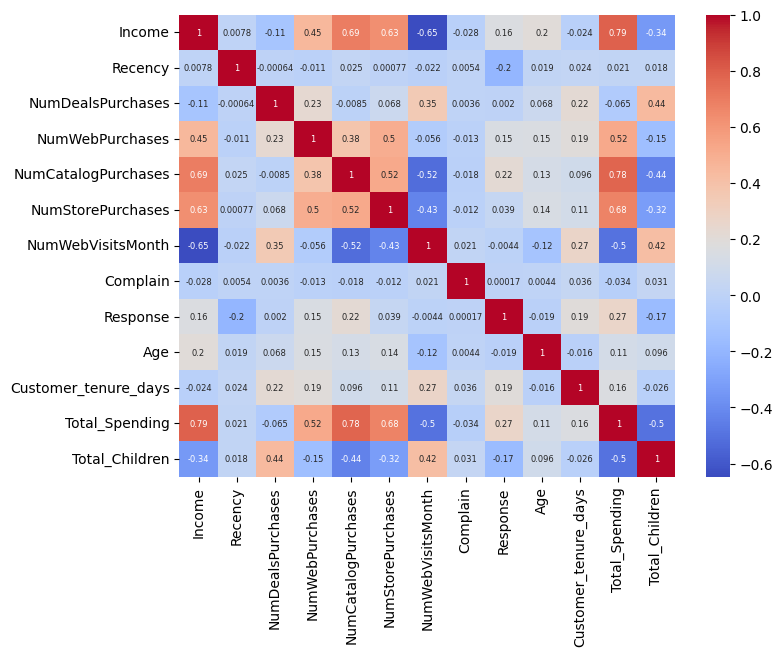

In [20]:
corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,annot_kws={'size':6},cmap='coolwarm')

# Feature Encoding

In [21]:
ohe = OneHotEncoder()

cat_cols = ['Education','Living_with']

encoded_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [22]:
enc_df = pd.DataFrame(encoded_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),
                     index=df_cleaned.index)

In [23]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)
df_encoded.shape

(2236, 18)

# Feature Scaling

In [24]:
x = df_encoded

In [25]:
ss = StandardScaler()
x_scaled = ss.fit_transform(x)

# Dimensionality Reduction -- PCA

In [26]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
x_pca = pca.fit_transform(x_scaled)

In [27]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D Projection')

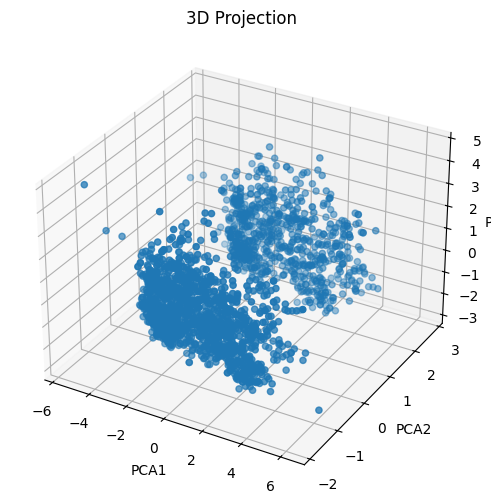

In [28]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.set_title('3D Projection')

# Analyze K value
# 1.Elbow Method

In [29]:
wcss = []
for k in range(1,11):
    km = KMeans(n_clusters = k, random_state=42)
    km.fit_predict(x_pca)
    wcss.append(km.inertia_)

In [30]:
knee = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
optimal_k = knee.elbow
print('best k =',optimal_k)

best k = 4


Text(0, 0.5, 'wcss')

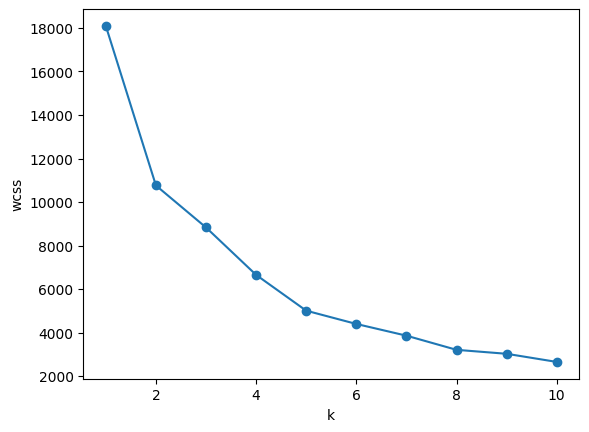

In [31]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel('k')
plt.ylabel('wcss')

# 2.Silhouette Score

In [32]:
scores = []
for k in range(2,11):
    km = KMeans(n_clusters = k, random_state=42)
    labels = km.fit_predict(x_pca)
    score = silhouette_score(x_pca,labels)
    scores.append(score)

Text(0, 0.5, 'silhouette score')

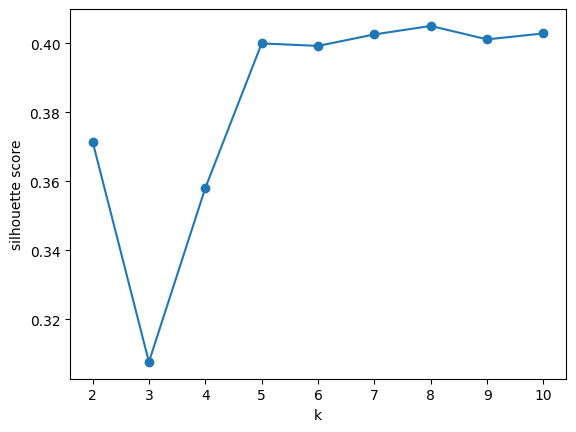

In [33]:
plt.plot(range(2,11),scores,marker='o')
plt.xlabel('k')
plt.ylabel('silhouette score')

Text(0, 0.5, 'ss')

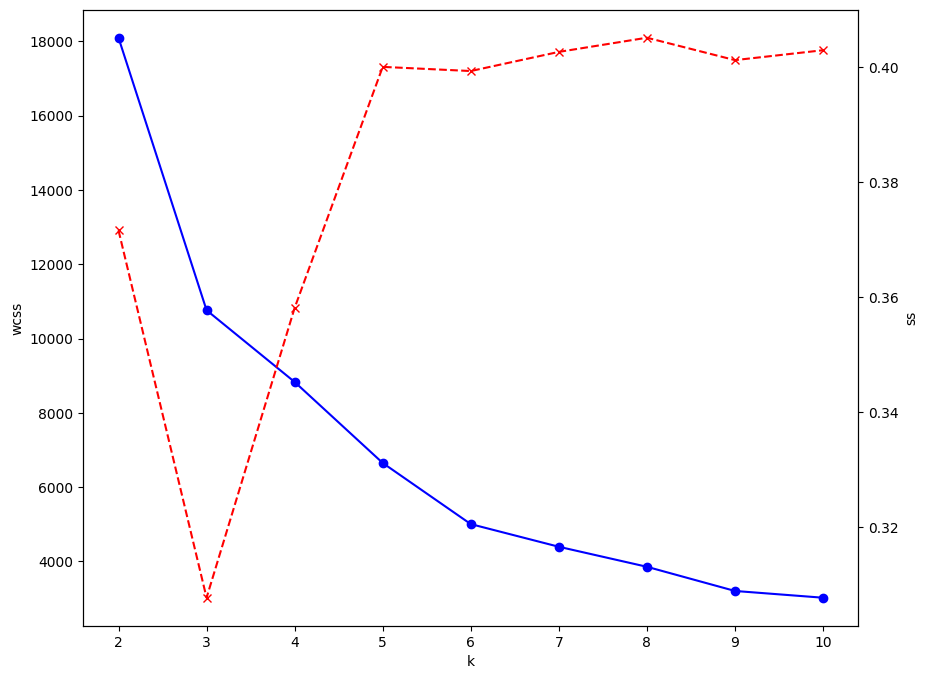

In [34]:
# combine plot
k_range=range(2,11)
fig,ax1 = plt.subplots(figsize=(10,8))
ax1.plot(k_range,wcss[:len(k_range)],marker='o',color='blue')
ax1.set_xlabel('k')
ax1.set_ylabel('wcss')

ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker='x',color='red',linestyle='--')
ax2.set_xlabel('k')
ax2.set_ylabel('ss')

# Clustering

In [35]:
#1 KMeans Clustering
km = KMeans(n_clusters=4,random_state=42)
labels = km.fit_predict(x_pca)

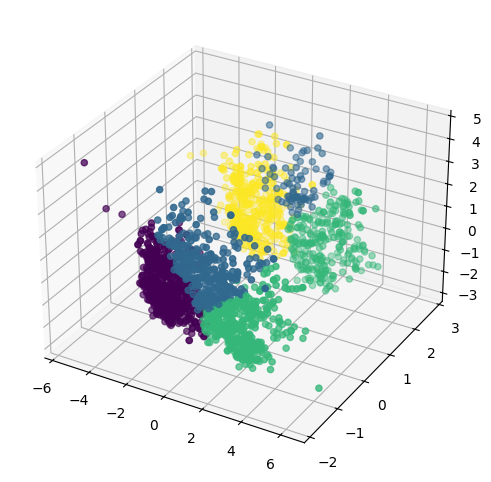

In [36]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels)

In [37]:
#2 Agglomerative Clustering
alc = AgglomerativeClustering(n_clusters = 4, linkage='ward')
labels_ag = alc.fit_predict(x_pca)

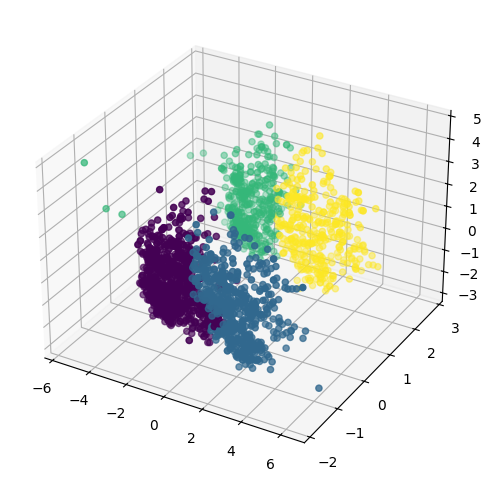

In [38]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_ag)

# Characterization of Clusters

In [39]:
x['cluster'] = labels_ag

In [40]:
x.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

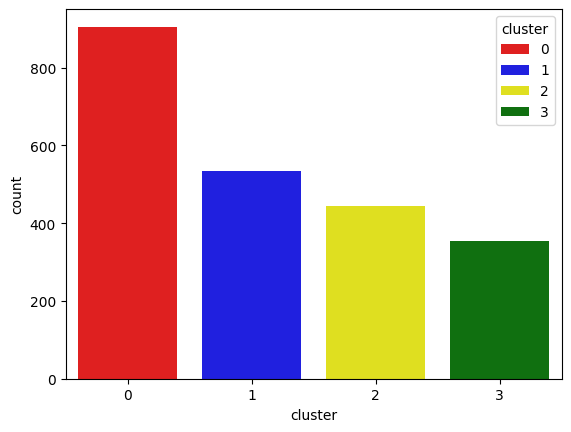

In [41]:
pal = ['red','blue','yellow','green']
sns.countplot(x=x['cluster'],palette = pal, hue=x['cluster'])

<Axes: xlabel='Total_Spending', ylabel='Income'>

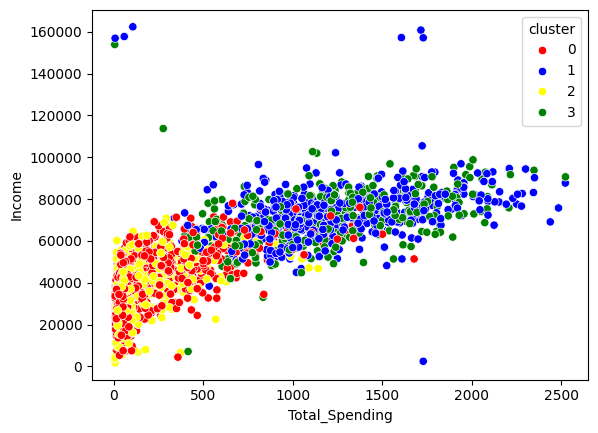

In [42]:
# Income & Spending patterns
sns.scatterplot(data = x, x='Total_Spending', y='Income',hue='cluster',palette=pal)

In [43]:
# Cluster Summary
cluster_summary = x.groupby('cluster').mean()
cluster_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
cluster,,,,,,,,,,,,,,,,,,
0,39680.580110,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,55.669613,342.939227,221.955801,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72808.445693,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,59.492509,369.720974,1236.588015,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36960.143018,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,55.691441,338.781532,165.702703,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70722.681303,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,58.932011,376.280453,1190.385269,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000
